In [3]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import cupy as cp
import tqdm

DATA_FOLDER = '/space/gzanardini/tuh_whole/split'

best_parameters = {
    'spectral': ('CAR',          20 ,    'std'),
    'cwt':      ('BipolarDB',   60,      'std'),
    'dwt':      ('Laplacian',   20,     'std'),
    'mst':      ('BipolarDB',   10,     'skew'),
    'sst':      ('CAR',         20,     'mean'),
    'cc':       ('Cz',          60,      'median'),
    'plv':      ('BipolarDB',   5,      'median'),
    'gcc':      ('Laplacian',         5,      'mean'),
    'gplv':     ('BipolarDB',   10,      'median'),
    'utm':      ('CAR',   1,     'median')
}

In [4]:
def load_data(no_ied=False):
    """Load and prepare the dataset."""
    description = pd.read_csv(f'{DATA_FOLDER}/description.csv')
    labels = description['epilepsy'].to_numpy()
    subjects = description['subject'].to_numpy()
    unique_subjects = np.unique(description['subject'])
    
    subject_labels = []
    for subj in unique_subjects:
        lbl = labels[subjects == subj][0]
        subject_labels.append([subj, lbl])
    subject_labels = np.array(subject_labels)

    return description, labels, subjects, unique_subjects, subject_labels

def load_feature_data(feature_name):
    """Load and preprocess feature data using the best parameters for the given feature."""
    montage, segment_length, combiner = best_parameters[feature_name]
    data = np.load(f'{DATA_FOLDER}/{feature_name}_{montage}_{segment_length}s_{combiner}.npy')
    data = handle_complex_numbers(data)
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
    return data, montage, segment_length, combiner

def handle_complex_numbers(features):
    """Handle complex numbers and infinite values in features."""
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

In [6]:
from typing import Iterable



def s_index_to_name(idx: int,
                    channels: Iterable[str]) -> str:
    """Map a zero-based spectral feature index to a human-readable name.

    Parameters
    ----------
    idx : int
        Index in the flattened spectral vector (single combiner row) generated
        by `run_spectral_analysis()` or a row of `run_spectral_seg2()`.
    montage : {'CAR','Cz','BipolarDB','Laplacian'}
        Montage used to compute the features; determines channel ordering.
    combiner : str, optional
        Segment aggregation label to include (mean, median, std, skewness, kurtosis).
        Omit or set None to exclude from the name (useful for whole-recording runs).
    lap_suffix : str
        Suffix appended to Laplacian channel labels; forwarded to get_montage_channels().
    bands : iterable of str
        Band labels in the order features were computed. Defaults to S_BANDS
        ('delta','theta','alpha','beta','gamma').

    Returns
    -------
    str
        e.g., 'S_delta_FP1', 'S_mean_alpha_O2_Lap', etc.

    Raises
    ------
    IndexError
        If idx is outside the valid range for the montage.
    """
    N = len(channels)
    bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
    B = len(bands)


    band_id, ch_id = divmod(idx, N)  # because layout is band-major: pow.T.flatten()
    band = bands[band_id]
    ch_label = channels[ch_id]

    parts = ['S']
    parts.append(band)
    parts.append(ch_label)
    return "_".join(parts)


channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

feature_names= [s_index_to_name(i, channels=channels) for i in range(95)]

Processing spectral:   0%|          | 0/30 [00:00<?, ?it/s]

Processing spectral: 100%|██████████| 30/30 [00:07<00:00,  4.19it/s]


Feature: spectral - montage: CAR, segment_length: 20, combiner: std


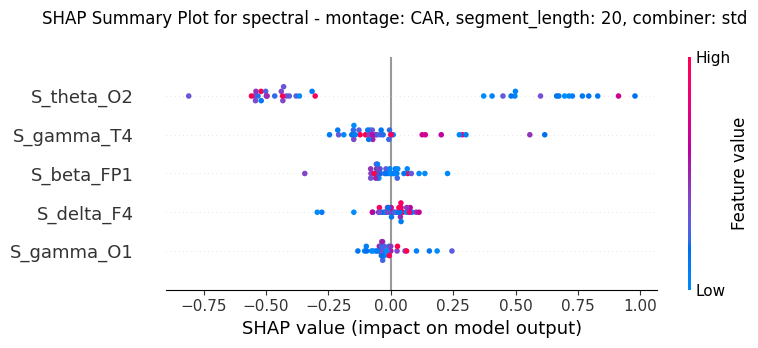

Processing cwt: 100%|██████████| 30/30 [00:08<00:00,  3.37it/s]

Feature: cwt - montage: BipolarDB, segment_length: 60, combiner: std


IndexError: list index out of range

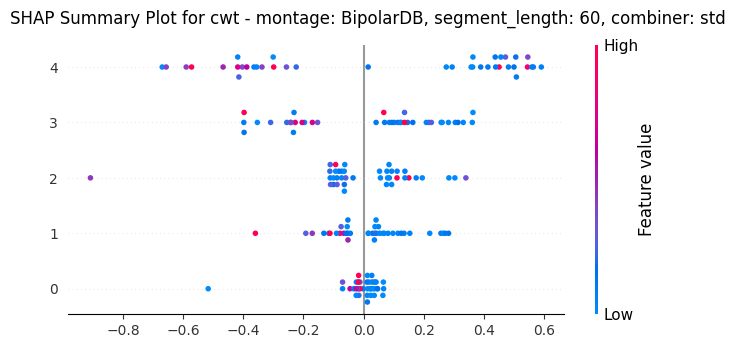

In [7]:
# for each of the best parameters, load the data and compute shapley values
for feature_name in best_parameters.keys():
    data, montage, segment_length, combiner = load_feature_data(feature_name)
    #load data
    description, labels, subjects, unique_subjects, subject_labels = load_data(no_ied=True)
    data = handle_complex_numbers(data)

    # delete from the data the rows whose description index is  for the subjects 'aaaaajgj' or 'aaaaakcd '
    data = data[~np.isin(subjects, ['aaaaajgj', 'aaaaakcd '])]
    # delete from the labels the rows whose description index is for the subjects 'aaaaajgj' or 'aaaaakcd '
    labels = labels[~np.isin(subjects, ['aaaaajgj', 'aaaaakcd '])]
    # delete from the subjects the rows whose description index is for the subjects 'aaaaajgj' or 'aaaaakcd '
    subjects = subjects[~np.isin(subjects, ['aaaaajgj', 'aaaaakcd '])]

    unique_subjects = unique_subjects[~np.isin(unique_subjects, ['aaaaajgj', 'aaaaakcd '])]
 
    shap_values_folds = []

    for subj in tqdm.tqdm(unique_subjects, desc=f'Processing {feature_name}'):


        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]

        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]

        ratio = (len(y_train) - sum(y_train)) / sum(y_train)



        model = XGBClassifier(scale_pos_weight=ratio,
                                n_jobs=4,  # Keep this as 1 since we're parallelizing at higher level
                                device='cpu',
                                n_estimators=100,
                                max_depth=6,
                                subsample=0.9,
                                gamma=0.1,
                                learning_rate=0.01
                            )

        model.fit(X_train, y_train)

        # Compute SHAP values
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer.shap_values(X_test)

        for shap_value in shap_values: 
            shap_values_folds.append(shap_value)

    print(f'Feature: {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')

    fig = plt.figure(figsize=(8, 5))
    plt.suptitle(f'SHAP Summary Plot for {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')
    ax0=fig.add_subplot(111)
    shap.summary_plot(
        np.array(shap_values_folds),
        data, max_display=5, show=False, feature_names=feature_names)   
    plt.tight_layout()
    if feature_name == 'spectral':
        plt.savefig(f'shap_summary_{feature_name}_tuh_without_ieds.pdf')
    plt.show()
    #shap.summary_plot(np.array(shap_values_folds),data, feature_names=data.columns if isinstance(data, pd.DataFrame) else None, max_display=7)
    